In [51]:
import sklearn as sk
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Settings:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', -1)

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\ipykernel_launcher.py:11: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  # This is added back by InteractiveShellApp.init_path()


In [52]:
df = pd.read_csv('housing.csv')

In [53]:
df.shape

(20640, 10)

In [54]:
df = df.dropna()
df.shape

(20433, 10)

In [55]:
for i in df.index:
    j = df.loc[i]
    if (j['median_house_value'] == 500001):
           df = df.drop(i)
df.shape

(19475, 10)

In [56]:
df = pd.get_dummies(df, columns=['ocean_proximity'])
df.shape

(19475, 14)

In [57]:
# In order to perform a Clustering Algorithm, We will:
# Calculate the Median, and then predict whether a house lies above the Median value or below.
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [58]:
median = df['median_house_value'].median()
median

173800.0

In [59]:
df['above_median'] = (df['median_house_value'] - median > 0)

In [60]:
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,above_median
10683,-117.77,33.53,32.0,3116.0,661.0,1105.0,543.0,5.1837,445600.0,1,0,0,0,0,True
1311,-121.84,37.99,15.0,2380.0,385.0,1292.0,388.0,4.6029,142600.0,0,1,0,0,0,False
5061,-118.28,33.99,35.0,1138.0,304.0,1128.0,311.0,1.8818,100000.0,1,0,0,0,0,False
132,-122.20,37.84,35.0,2865.0,460.0,1072.0,443.0,7.4882,319300.0,0,0,0,1,0,True
17638,-121.91,37.28,29.0,5650.0,817.0,2098.0,813.0,6.4285,337300.0,1,0,0,0,0,True


In [61]:
X = df.drop(['above_median', 'median_house_value'], axis=1)
Y = df['above_median']

In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [63]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((15580, 13), (15580,), (3895, 13), (3895,))

In [64]:
from sklearn.linear_model import LogisticRegression as lr
model = lr(solver='liblinear').fit(x_train, y_train)

In [65]:
print("Training Score: ", model.score(x_train, y_train))

Training Score:  0.8214377406931964


In [66]:
y_pred = model.predict(x_test)

In [67]:
df_pred_actual = pd.DataFrame({'predicted: ': y_pred, 'actual': y_test})
df_pred_actual

,predicted:,actual
1786,False,False
8525,True,True
11136,True,True
11717,False,True
6891,False,False
2465,False,False
16856,True,True
12665,False,False
2144,False,False
18981,False,False


In [68]:
from sklearn.metrics import accuracy_score

print("Test Score: ", accuracy_score(y_test, y_pred))

Test Score:  0.8205391527599486


# Ridge Regression

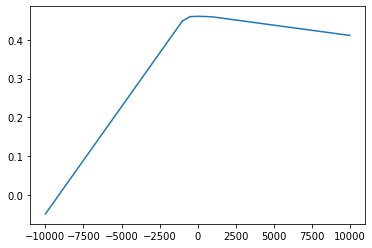

In [70]:
from sklearn.linear_model import Ridge
alpha_values = [-10000, -1000, -500, -100, -50, 1, 50, 100, 500, 1000, 10000]
results = []
for i in alpha_values:
    ridge = Ridge(alpha=i).fit(x_train, y_train)
    s = ridge.score(x_test, y_test)
    results.append(s)
plt.plot(alpha_values, results)
# Thus we can conclude that Linear Regression works better in this case than Ridge Regression. 

[0.025440417086535216]


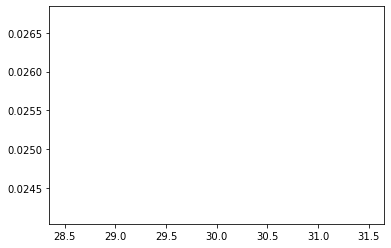

In [77]:
from sklearn.linear_model import Lasso
alpha_values = [30]
results = []
for i in alpha_values:
    lasso = Lasso(alpha=i).fit(x_train, y_train)
    s = lasso.score(x_test, y_test)
    results.append(s)
print(results)
plt.plot(alpha_values, results)